In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('train-test.csv')
df

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,TR-047996,Reno,Baton Rouge,39.54838,-118.64843,30.50134,-92.65374,1830.9,Flatbed,31786.0,2025-10-31,0.98865,2.05626,3787.32
47996,TR-047997,Greensboro,Memphis,35.98195,-82.78379,35.56802,-89.52871,445.8,Reefer,37465.0,2025-10-31,1.03034,1.51985,1171.93
47997,TR-047998,Greensboro,Cincinnati,35.98195,-82.78379,37.15706,-86.77499,267.9,Flatbed,24528.0,2025-10-31,1.00846,1.46954,713.36
47998,TR-047999,Memphis,Reno,35.56802,-89.52871,39.54838,-118.64843,1901.3,Flatbed,37581.0,2025-10-31,1.00014,2.05132,3987.46


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [4]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


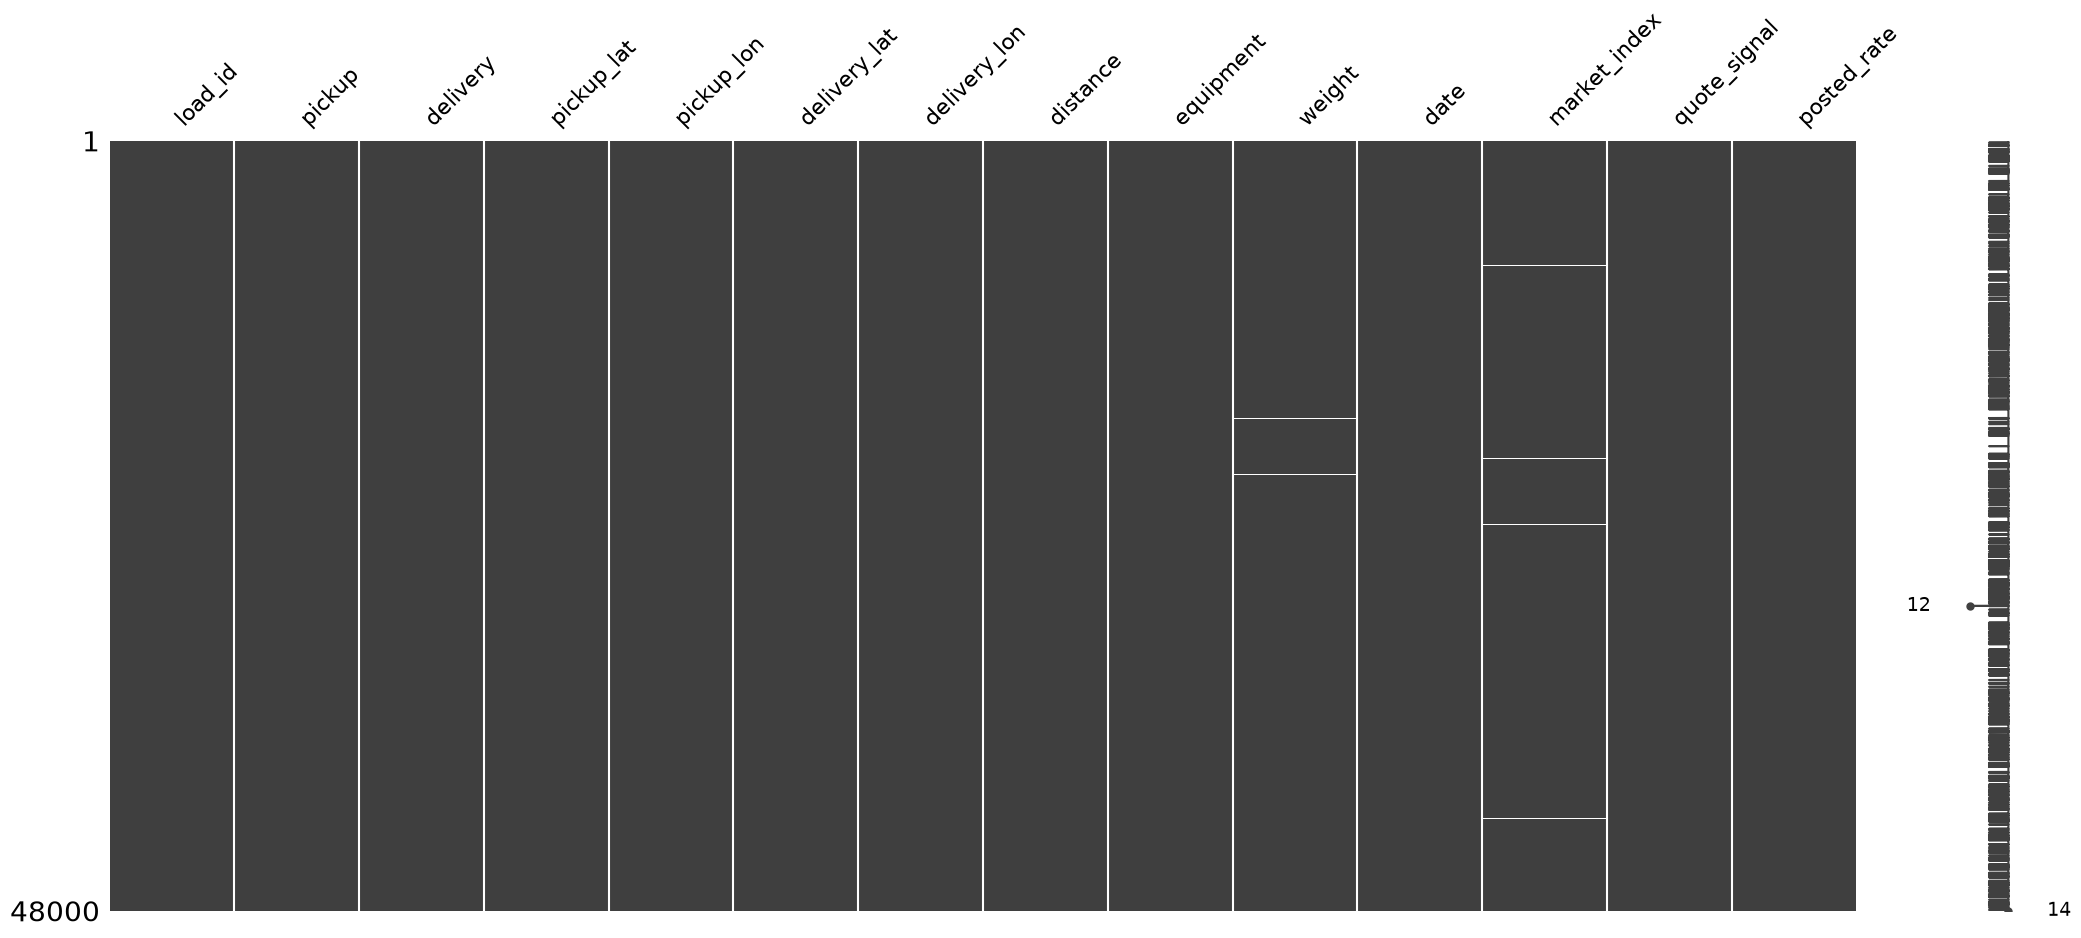

In [5]:
msno.matrix(df);

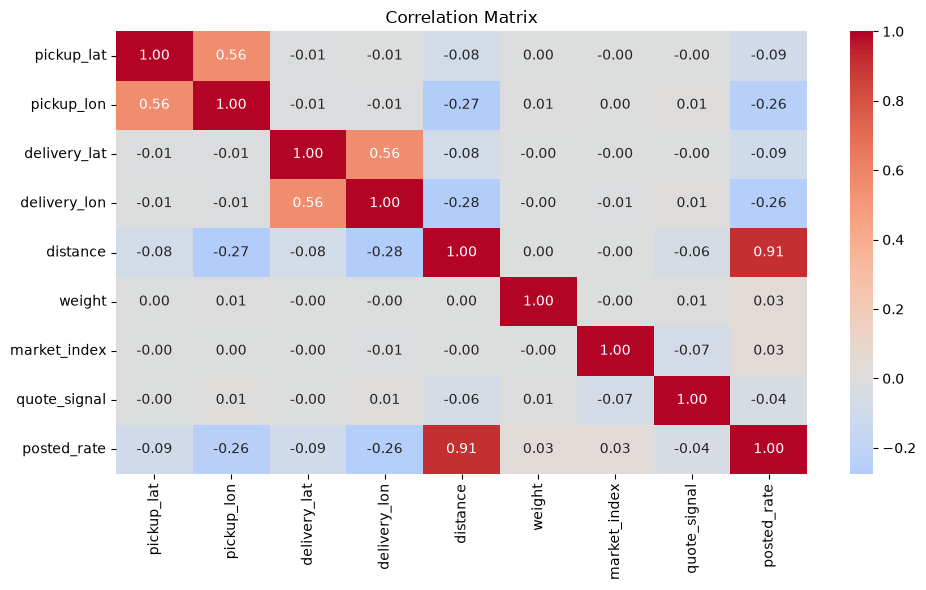

Saved: correlation_matrix.png


In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=110)
plt.show()
print("Saved: correlation_matrix.png")

In [7]:
df.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [8]:
df.duplicated().sum()  

np.int64(0)

In [9]:
df.nunique()    

load_id         48000
pickup             64
delivery           64
pickup_lat         64
pickup_lon         63
delivery_lat       64
delivery_lon       63
distance        21204
equipment           3
weight          23678
date              304
market_index    32884
quote_signal    37633
posted_rate     45398
dtype: int64

In [10]:
(df['weight'] < 0).sum()

np.int64(292)

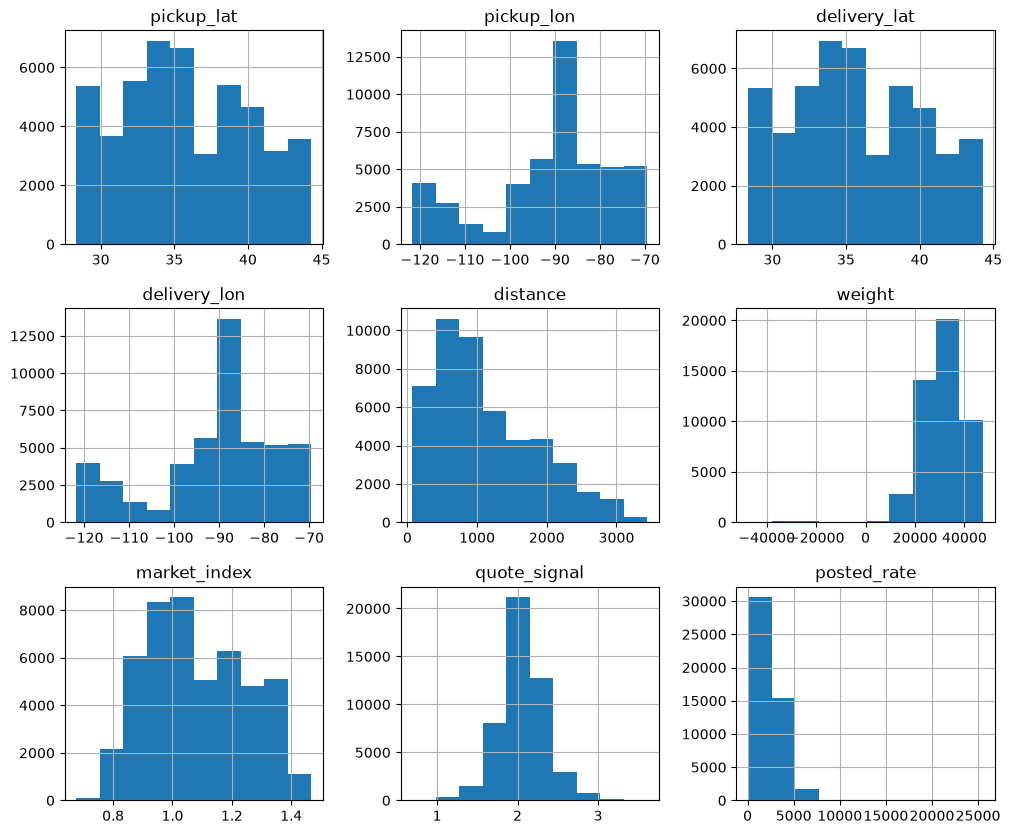

In [11]:
df.hist(figsize=(12,10));

In [12]:
df.skew(numeric_only=True)

pickup_lat      0.177336
pickup_lon     -0.693987
delivery_lat    0.179351
delivery_lon   -0.699329
distance        0.765775
weight         -1.910391
market_index    0.214263
quote_signal    0.171989
posted_rate     1.902395
dtype: float64

In [15]:
df.loc[df['weight'] >= 0, 'weight'].describe()

count    47408.000000
mean     31415.358674
std       7994.902979
min       5000.000000
25%      25922.000000
50%      31493.500000
75%      37063.000000
max      47500.000000
Name: weight, dtype: float64

In [16]:
df['weight'].abs().describe()

count    47700.000000
mean     31417.249245
std       7996.515399
min       5000.000000
25%      25922.000000
50%      31496.000000
75%      37063.250000
max      47500.000000
Name: weight, dtype: float64

In [17]:
df['weight'] = df['weight'].abs()

In [18]:
df.describe() # checking the weight

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31417.249245,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,7996.515399,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,5000.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25922.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31496.000000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37063.250000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [19]:
(df['weight'] < 0).sum() # no negative values for weight

np.int64(0)

In [20]:
df.corr(numeric_only=True)['posted_rate'].sort_values(ascending=False)

posted_rate     1.000000
distance        0.908519
weight          0.041343
market_index    0.034165
quote_signal   -0.039858
pickup_lat     -0.090873
delivery_lat   -0.091970
pickup_lon     -0.255058
delivery_lon   -0.257086
Name: posted_rate, dtype: float64

In [21]:
df.groupby('equipment')['posted_rate'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
equipment,,,,
Dry Van,27202,2271.548686,1953.035,1423.029914
Flatbed,8753,2445.087223,2076.810,1505.053087
Reefer,12045,2553.636939,2196.670,1589.670824


In [22]:
df.groupby('equipment')['posted_rate'].describe()

,count,mean,std,min,25%,50%,75%,max
equipment,,,,,,,,
Dry Van,27202.0,2271.548686,1423.029914,57.22,1196.125,1953.035,3193.5025,25533.00
Flatbed,8753.0,2445.087223,1505.053087,157.76,1288.670,2076.810,3469.1200,17893.17
Reefer,12045.0,2553.636939,1589.670824,63.36,1361.270,2196.670,3588.2900,24140.21


In [23]:
df.groupby(['equipment', 'pickup'])['posted_rate'].mean()

equipment  pickup     
Dry Van    Albany         2836.877179
           Albuquerque    2741.814364
           Amarillo       2488.732718
           Atlanta        1714.797799
           Austin         2231.442597
                             ...     
Reefer     Tampa          2377.809147
           Toledo         2276.700719
           Tucson         3441.034267
           Tulsa          2072.245030
           Washington     2232.769655
Name: posted_rate, Length: 192, dtype: float64

In [24]:
df.groupby('equipment')['posted_rate'].mean().sort_values(ascending=False)

equipment
Reefer     2553.636939
Flatbed    2445.087223
Dry Van    2271.548686
Name: posted_rate, dtype: float64

In [25]:
df_clean = df.dropna(subset=['weight', 'market_index'])

In [26]:
print(f"Rows removed: {len(df) - len(df_clean)} ({(1-len(df_clean)/len(df))*100:.2f}%)")
print(f"Rows remaining: {len(df_clean):,}")

Rows removed: 673 (1.40%)
Rows remaining: 47,327


In [27]:
df['date'] = pd.to_datetime(df['date'])

In [28]:
df['month'] = df['date'].dt.month   

In [29]:
df['week'] = df['date'].dt.isocalendar().week

In [30]:
df['day_of_week'] = df['date'].dt.dayofweek 

In [31]:
print(f"Extracted time features from date:")
print(f" - month: {df['month'].min()}-{df['month'].max()}")
print(f" - week: {df['week'].min()}-{df['week'].max()}")
print(f" - day_of_week: {df['day_of_week'].min()}-{df['day_of_week'].max()}")

Extracted time features from date:
 - month: 1-10
 - week: 1-44
 - day_of_week: 0-6


In [32]:
load_ids = df['load_id']

In [33]:
y = df['posted_rate']

In [34]:
X = df[['distance', 'weight', 'market_index', 'quote_signal', 'equipment', 'month']]

In [35]:
le = LabelEncoder()
X['equipment'] = le.fit_transform(X['equipment'])

print(f"Encoded 'equipment':")
for i, cat in enumerate(le.classes_):
    print(f"  {cat}: {i}")
 
print(f"\n dtypes after encoding:")
print(X.dtypes)

Encoded 'equipment':
  Dry Van: 0
  Flatbed: 1
  Reefer: 2

 dtypes after encoding:
distance        float64
weight          float64
market_index    float64
quote_signal    float64
equipment         int64
month             int32
dtype: object


C:\Users\PC\AppData\Local\Temp\ipykernel_19556\1812574072.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['equipment'] = le.fit_transform(X['equipment'])


In [36]:
#Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
print(f"Data prepared:")
print(f"  Training: {len(X_train):,} rows")
print(f"  Testing:  {len(X_test):,} rows")

Data prepared:
  Training: 38,400 rows
  Testing:  9,600 rows


In [37]:
print(f"Split complete (random_state=42 for reproducibility)")
print(f"\n  Training set:   {len(X_train):,} rows (80%)")
print(f"  Test set:       {len(X_test):,} rows (20%)")

Split complete (random_state=42 for reproducibility)

  Training set:   38,400 rows (80%)
  Test set:       9,600 rows (20%)


In [38]:
X_train = X_train.dropna()
X_test = X_test.dropna()
y_train = y_train[X_train.index]
y_test = y_test[X_test.index]

In [39]:
# Linear Regression
print("\n1. Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression trained")


1. Training Linear Regression...
Linear Regression trained


In [40]:
#Model Training
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1 
)

print("Training model...")
model.fit(X_train, y_train)
print("Model trained")

Training model...
Model trained


In [41]:
print("2. Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest trained")

2. Training Random Forest...
Random Forest trained


In [42]:
# Linear Regression predictions
y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test = lr_model.predict(X_test)
 
# Random Forest predictions
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)
 
print("Predictions complete for both models")

Predictions complete for both models


In [43]:
#Performance Metrics Comparison
# Linear Regression metrics
mae_lr_train = mean_absolute_error(y_train, y_pred_lr_train)
mae_lr_test = mean_absolute_error(y_test, y_pred_lr_test)
r2_lr_train = r2_score(y_train, y_pred_lr_train)
r2_lr_test = r2_score(y_test, y_pred_lr_test)
rmse_lr_test = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
 
# Random Forest metrics
mae_rf_train = mean_absolute_error(y_train, y_pred_rf_train)
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)
r2_rf_train = r2_score(y_train, y_pred_rf_train)
r2_rf_test = r2_score(y_test, y_pred_rf_test)
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
 
# Display results
print("\nLINEAR REGRESSION:")
print(f"  Training MAE:   ${mae_lr_train:.2f}")
print(f"  Testing MAE:    ${mae_lr_test:.2f}  ← More important (real metric)")
print(f"  Training R²:    {r2_lr_train:.4f}")
print(f"  Testing R²:     {r2_lr_test:.4f}")
print(f"  RMSE (test):    ${rmse_lr_test:.2f}")
 
print("\nRANDOM FOREST:")
print(f"  Training MAE:   ${mae_rf_train:.2f}")
print(f"  Testing MAE:    ${mae_rf_test:.2f}  ← More important (real metric)")
print(f"  Training R²:    {r2_rf_train:.4f}")
print(f"  Testing R²:     {r2_rf_test:.4f}")
print(f"  RMSE (test):    ${rmse_rf_test:.2f}")
 
improvement = ((mae_lr_test - mae_rf_test) / mae_lr_test) * 100
print(f"\n RANDOM FOREST is better!")
print(f"  Improvement: ${mae_lr_test - mae_rf_test:.2f} ({improvement:.1f}% more accurate)")
print(f"  On 1000 loads/year: ${(mae_lr_test - mae_rf_test) * 1000:.0f} better accuracy")


LINEAR REGRESSION:
  Training MAE:   $146.90
  Testing MAE:    $139.60  ← More important (real metric)
  Training R²:    0.8277
  Testing R²:     0.8652
  RMSE (test):    $536.85

RANDOM FOREST:
  Training MAE:   $62.15
  Testing MAE:    $130.65  ← More important (real metric)
  Training R²:    0.9724
  Testing R²:     0.8501
  RMSE (test):    $566.18

 RANDOM FOREST is better!
  Improvement: $8.95 (6.4% more accurate)
  On 1000 loads/year: $8948 better accuracy


In [44]:
# Evaluate

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
 
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
 
print(f"\nTraining Performance:")
print(f"  MAE:  ${mae_train:.2f}")
print(f"  R²:   {r2_train:.4f}")
 
print(f"\nTest Performance (real metric):")
print(f"  MAE:  ${mae_test:.2f}")
print(f"  R²:   {r2_test:.4f}")


Training Performance:
  MAE:  $62.15
  R²:   0.9724

Test Performance (real metric):
  MAE:  $130.65
  R²:   0.8501


In [45]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
 
print(feature_importance.to_string(index=False))

     feature  importance
    distance    0.871454
quote_signal    0.043244
market_index    0.033421
      weight    0.032625
   equipment    0.010123
       month    0.009132
